# Zadania do samodzielnego wykonania

1)

Proszę stworzyć zestaw punktów należących do dwóch klas: **K1** i **K2**.  Punkty z klasy **K1** powinny być losowane z rozkładu normalnego o średniej **[0, -1]** i wariancji **1**. Punkty z klasy **K2** powinny pochodzić z rozkładu normalnego o średniej **[1, 1]** i wariancji **1**. Całościowo zbiór powinien zawierać **200 punktów**, po 100 dla każdej klasy.   
Należy wybrać **zbiory uczące** o następującej liczebności: **5, 10, 20 oraz 100**.  Dla każdego wariantu podziału znalezy znaleźć równanie **prostej**, która najlepiej oddziela klasy **K1** i **K2**. Uzyskaną prostą należy
zaprezentować razem z punktami testowymi i linią (hiperpłaszczyzną), która oddziela klasy. Następnie należy ocenić to jak dobrze klasyfikator działa od proporcji danych uczących i testujących.

2)

Proszę pobrać zbiór https://archive.ics.uci.edu/ml/datasets/iris. Można to też zrobić w pythonie używając funkcji sklearn.datasets.load_iris(). Następnie proszę dokonać samodzielnego podziału na dane uczące i testujące w proporcji **80%/20%**. Proszę zbudować sieć złożoną z pojedynczej warstwy perceptronów (np. używając omawianej już tutaj funkcji sklearn.linear_model.Perceptron), której zadaniem będzie jak najdokładniejsza klasyfikacja gatunków irysów na podstawie ich pomiarów. Proszę dokonać analizy macierzy pomyłek dla kilku uruchomień algorytmu. Zachęcam do rozważenia pytania: jaką największą trafność jest w stanie uzyskać w klasyfikacji irysów z podanego zbioru pojedyncza warstwa perceptronów? Dlaczego? (Podpowiedź: polecamy przyjrzeć się pojęciu liniowej separowalności)

3)

Proszę spróbować podzielić zbiór irysów na zbiór uczący i testujący na co najmniej 3 różne sposoby. Jak duży jest wpływ podziału na wynik?

4)

Proszę sprawdzić wpływ ilości epok na poprawność klasyfikacji zbioru irysów z poprzednich zadań, dla wybranych ilości epok (polecamy spróbować od jak najmniejszej, np. od 1 lub 2 epok). Żeby zapobiec wcześniejszemu przerywaniu uczenia, w pakiecie Sklearn można ustalić argument tol na odpowiednio małą liczbę czy ustawiając argument early_stopping na False. Można też zamiast tego (lub dodatkowo) nie wyłączać tych kryteriów i zamiast tego prawdzić wartość ilość faktycznych epok potrzebnych do ich osiągnięcia (n_iter_) Proszę przedstawić wnioski, np. na wykresie zależności średniej trafności klasyfikacji na zbiorze testującym w zależności od liczby epok.

# Zadanie 1

In [1]:
import numpy as np
from sklearn.linear_model import Perceptron

K1 = np.random.multivariate_normal([0, -1], [[1, 0], [0, 1]], size=100)
K2 = np.random.multivariate_normal([1, 1], [[1, 0], [0, 1]], size=100)

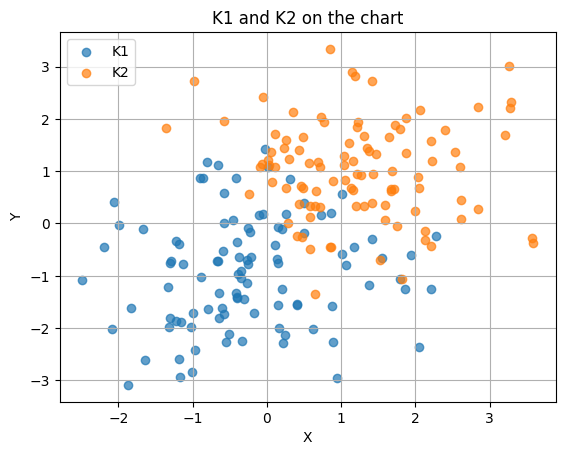

In [2]:
import matplotlib.pyplot as plt

plt.scatter(K1[:, 0], K1[:, 1], label='K1', alpha=0.7)
plt.scatter(K2[:, 0], K2[:, 1], label='K2', alpha=0.7)

plt.title("K1 and K2 on the chart")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.legend()

plt.show()

In [3]:
def teachNeuron(K1learn, K2learn):
    #Dane na wykresie
    plt.figure()
    plt.scatter(K1learn[:,0], K1learn[:, 1])
    plt.scatter(K2learn[:, 0], K2learn[:,1])
    plt.title("K1 and K2 on the chart")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.legend(['K1', 'K2'])
    
    # przygotowujemy wzorcowe dane uczące. X to współrzędne, y to klasa, do której należą
    X = np.vstack((K1learn, K2learn))
    y = [0]*len(K1learn)+[1]*len(K1learn)
    
    # przygotowujemy perceptron.
    neuron = Perceptron(tol=1e-3, max_iter = 20)

    # uczymy neuron przez wskazaną liczbę epok lub do zatrzymania się uczenia
    neuron.fit(X, y)

    
    
    # możemy sprawdzić jak udane było uczenie:
    print("Jakość nauki neuron.score(X, y): ",neuron.score(X, y))
    print("Wagi neuron.coef_[0]): ",neuron.coef_[0])
    print("Bias: ",neuron.intercept_[0])

    #Tylko na danych uczących
    x1=np.linspace(-5, 5, 100)
    x2 = -(1./neuron.coef_[0][1])*(neuron.coef_[0][0]*x1 + neuron.intercept_[0])
    plt.plot(x1, x2, '-r')
    plt.title(f"K1 i K2 dla zbioru liczebności: {len(K1learn)}")
    plt.show()
    
    #Na całym zbiorze
    plt.figure()
    plt.scatter(K1[:,0], K1[:, 1])
    plt.scatter(K2[:, 0], K2[:,1])
    plt.title("K1 and K2 on the chart")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.legend(['K1', 'K2'])
    plt.plot(x1, x2, '-r')
    plt.show()

    return neuron.coef_[0], neuron.intercept_[0]

def buildConfusionMatrix(k1, k2, wagi, bias):
    y_true = [0] * len(k1) + [1] * len(k2)
    X_all = np.vstack((k1, k2))
    

    scores = np.dot(X_all, wagi) + bias
    y_pred = (scores > 0).astype(int) 
    
    from sklearn import metrics
    cm = metrics.confusion_matrix(y_true, y_pred)
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['K1', 'K2'])
    cm_display.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    accuracy = metrics.accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.2%}")
    


Dla 5:


Jakość nauki neuron.score(X, y):  1.0
Wagi neuron.coef_[0]):  [0.39641266 1.8854409 ]
Bias:  -2.0


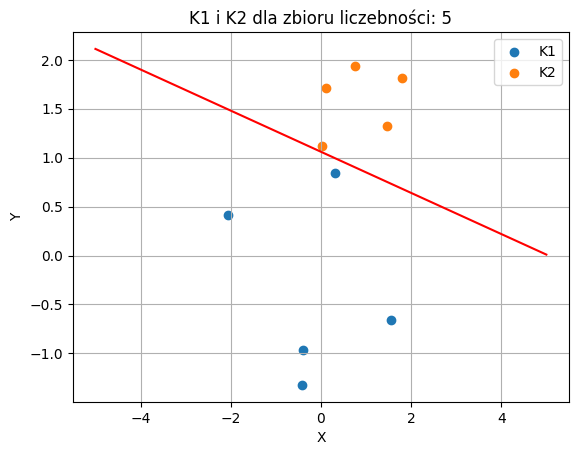

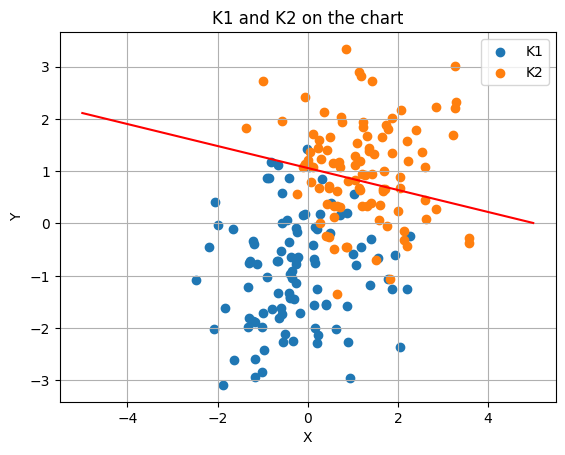

Dla danych do nauki


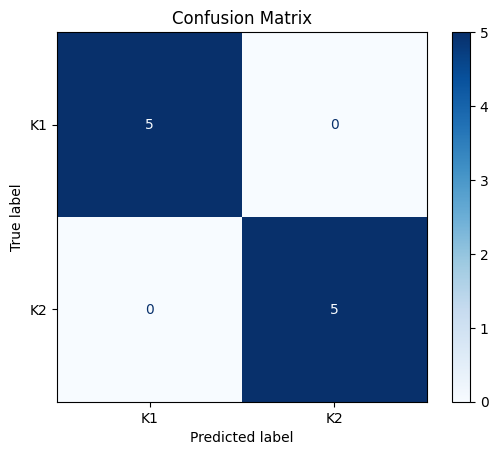

Accuracy: 100.00%
Dla danych testowych


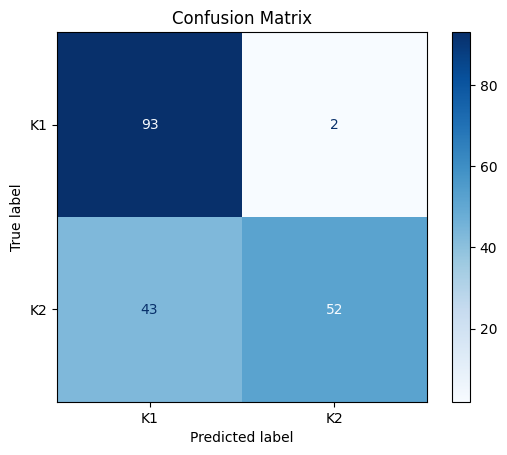

Accuracy: 76.32%


In [4]:
wagi, bias = teachNeuron(K1[0:5], K2[0:5])
print("Dla danych do nauki")
buildConfusionMatrix(K1[0:5], K2[0:5], wagi, bias)
print("Dla danych testowych")
buildConfusionMatrix(K1[5:], K2[5:], wagi, bias)



Dla 10:

Jakość nauki neuron.score(X, y):  0.95
Wagi neuron.coef_[0]):  [1.59875957 3.68350768]
Bias:  -2.0


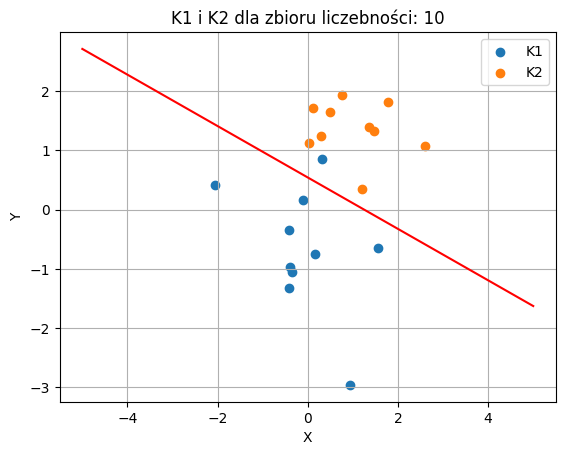

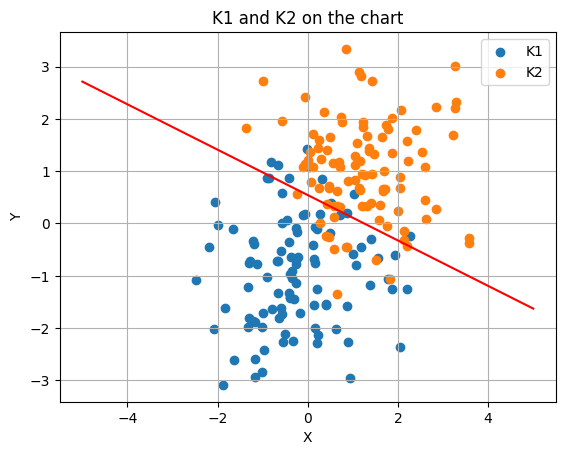

Dla danych do nauki


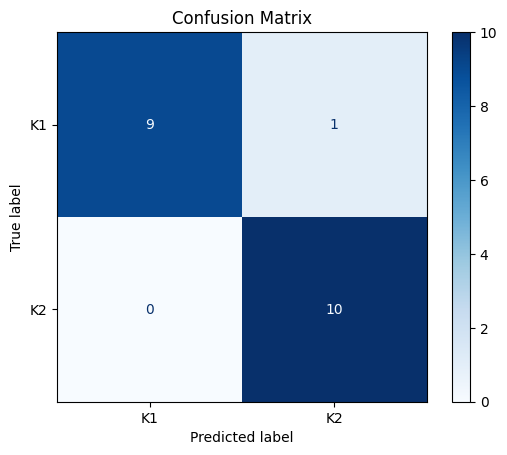

Accuracy: 95.00%
Dla danych testowych


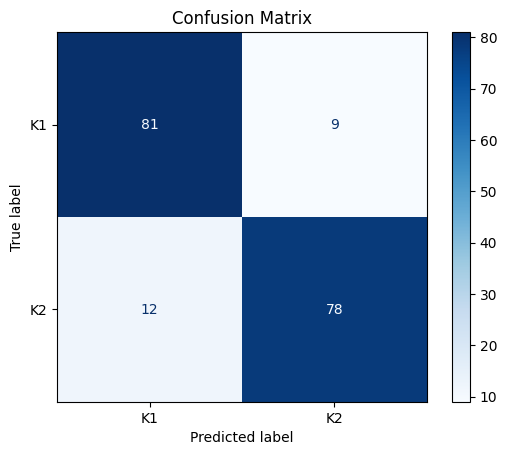

Accuracy: 88.33%


In [5]:
wagi, bias=teachNeuron(K1[0:10], K2[0:10])
print("Dla danych do nauki")
buildConfusionMatrix(K1[0:10], K2[0:10], wagi, bias)
print("Dla danych testowych")
buildConfusionMatrix(K1[10:], K2[10:], wagi, bias)

Dla 20:

Jakość nauki neuron.score(X, y):  0.925
Wagi neuron.coef_[0]):  [1.95212316 1.45341156]
Bias:  -1.0


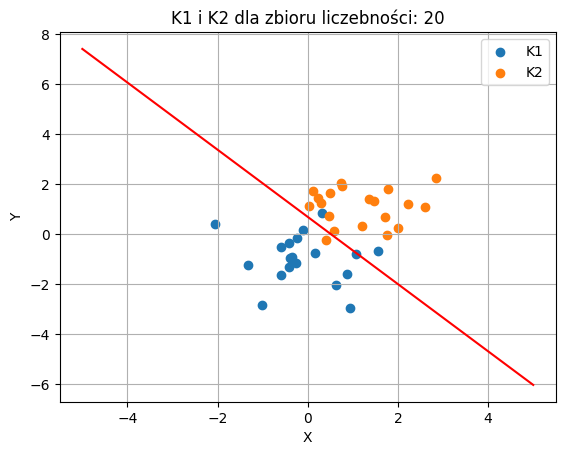

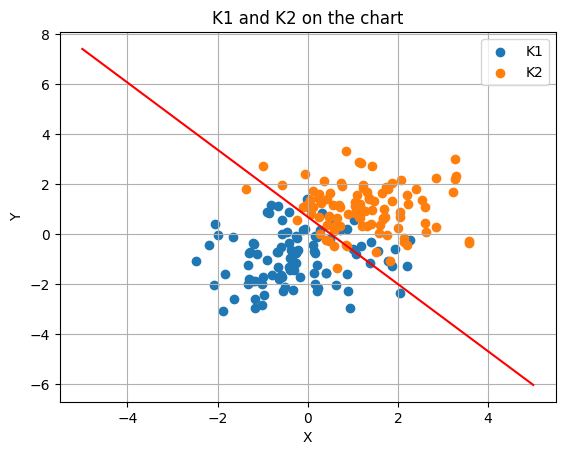

Dla danych do nauki


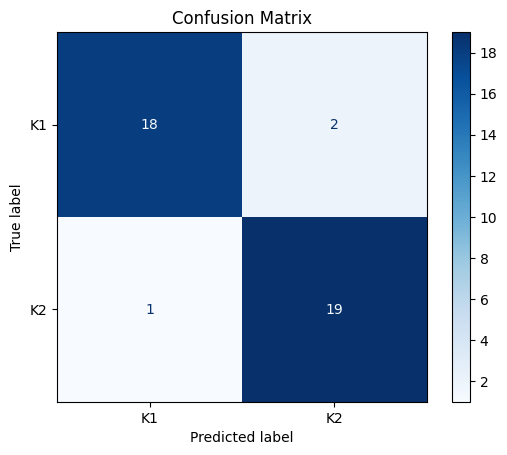

Accuracy: 92.50%
Dla danych testowych


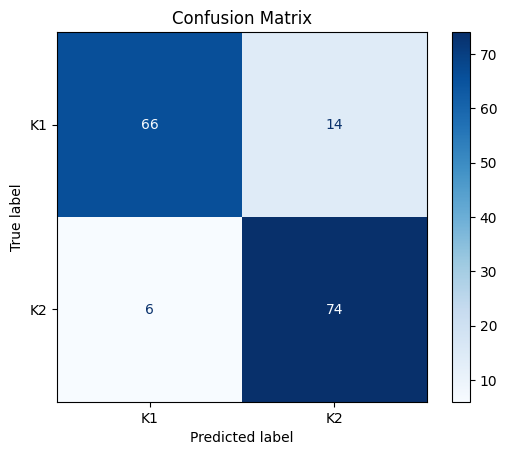

Accuracy: 87.50%


In [6]:
wagi, bias = teachNeuron(K1[0:20], K2[0:20])
print("Dla danych do nauki")
buildConfusionMatrix(K1[0:20], K2[0:20], wagi, bias)
print("Dla danych testowych")
buildConfusionMatrix(K1[20:], K2[20:], wagi, bias)

Dla 100:

Jakość nauki neuron.score(X, y):  0.845
Wagi neuron.coef_[0]):  [4.57318779 1.88318869]
Bias:  -2.0


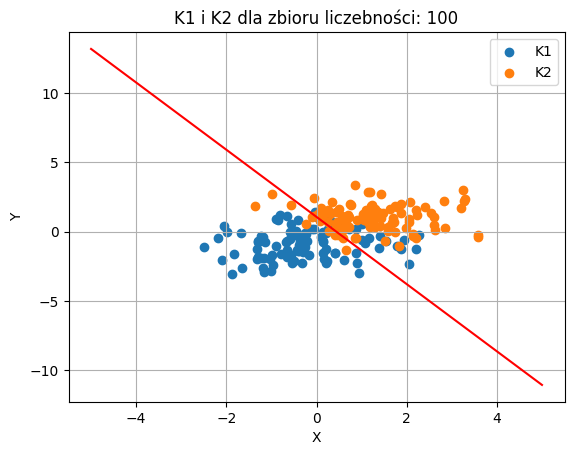

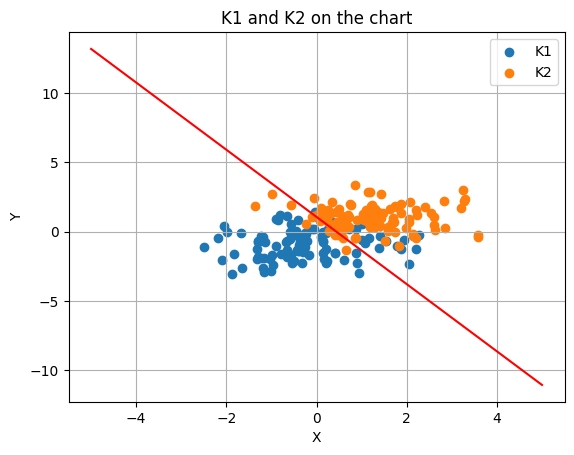

Dla danych do nauki


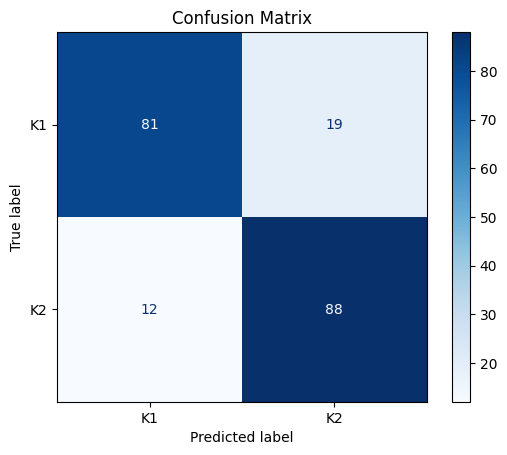

Accuracy: 84.50%


In [7]:
wagi, bias = teachNeuron(K1[0:100], K2[0:100])
print("Dla danych do nauki")
buildConfusionMatrix(K1, K2, wagi, bias)

# Zadanie 2


Proszę pobrać zbiór https://archive.ics.uci.edu/ml/datasets/iris. Można to też zrobić w pythonie używając funkcji sklearn.datasets.load_iris(). Następnie proszę dokonać samodzielnego podziału na dane uczące i testujące w proporcji 80%/20%. Proszę zbudować sieć złożoną z pojedynczej warstwy perceptronów (np. używając omawianej już tutaj funkcji sklearn.linear_model.Perceptron), której zadaniem będzie jak najdokładniejsza klasyfikacja gatunków irysów na podstawie ich pomiarów. Proszę dokonać analizy macierzy pomyłek dla kilku uruchomień algorytmu. Zachęcam do rozważenia pytania: jaką największą trafność jest w stanie uzyskać w klasyfikacji irysów z podanego zbioru pojedyncza warstwa perceptronów? Dlaczego? (Podpowiedź: polecamy przyjrzeć się pojęciu liniowej separowalności)


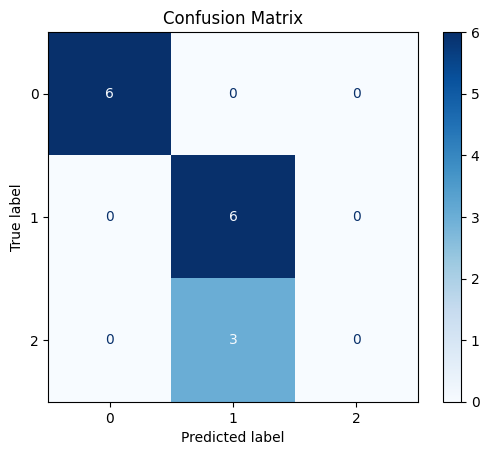

 Accuracy: 80.00%


In [24]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import metrics

dataset = sklearn.datasets.load_iris()

X=dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

perceptron_layer = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron_layer.fit(X_train, y_train)

y_pred = perceptron_layer.predict(X_test)

cm = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2'])
cm_display.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
print(f" Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Zadanie 3

Proszę spróbować podzielić zbiór irysów na zbiór uczący i testujący na co najmniej 3 różne sposoby. Jak duży jest wpływ podziału na wynik?

# Zadanie 4


Proszę sprawdzić wpływ ilości epok na poprawność klasyfikacji zbioru irysów z poprzednich zadań, dla wybranych ilości epok (polecamy spróbować od jak najmniejszej, np. od 1 lub 2 epok). Żeby zapobiec wcześniejszemu przerywaniu uczenia, w pakiecie Sklearn można ustalić argument tol na odpowiednio małą liczbę czy ustawiając argument early_stopping na False. Można też zamiast tego (lub dodatkowo) nie wyłączać tych kryteriów i zamiast tego prawdzić wartość ilość faktycznych epok potrzebnych do ich osiągnięcia (n_iter_) Proszę przedstawić wnioski, np. na wykresie zależności średniej trafności klasyfikacji na zbiorze testującym w zależności od liczby epok.

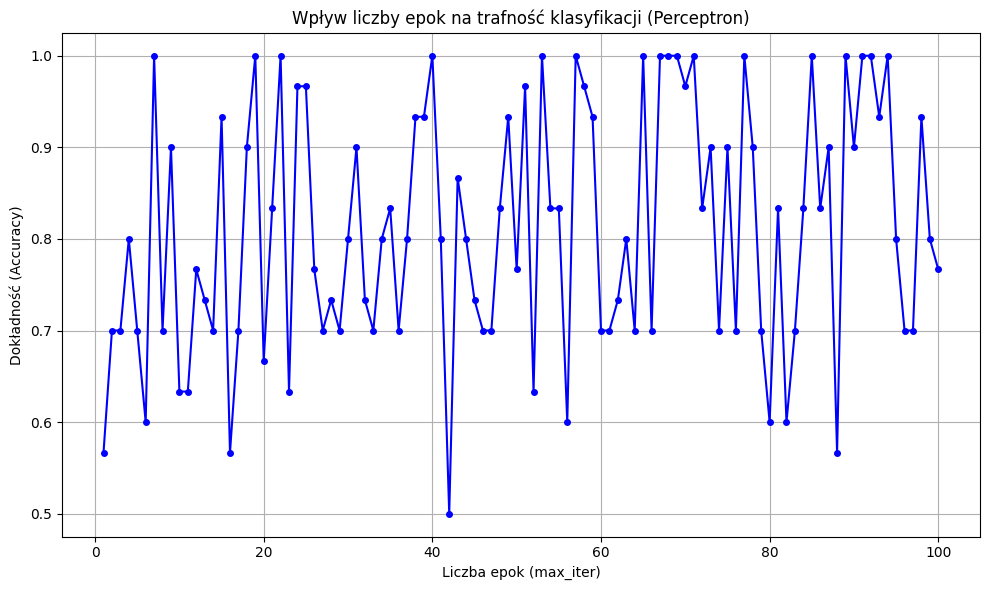

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

epochs_list = list(range(1, 101))
accuracies = []

for epochs in epochs_list:
    clf = Perceptron(max_iter=epochs, tol=None, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, accuracies, marker='o', linestyle='-', markersize=4, color='b')
plt.title('Wpływ liczby epok na trafność klasyfikacji (Perceptron)')
plt.xlabel('Liczba epok (max_iter)')
plt.ylabel('Dokładność (Accuracy)')
plt.grid(True)
plt.tight_layout()
plt.savefig('epochs_accuracy.png')